In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import torch
import json
import argparse
import numpy as np
import os
from pathlib import Path
import torch.nn.functional as F
from mpl_toolkits.axes_grid1 import make_axes_locatable
import glob
# Import project-specific modules
import monai
from monai.utils import set_determinism
from utils_main import *
from utils_GANSim import *
import torchvision.transforms as T
from PIL import Image
from generative.inferers import LatentDiffusionInferer
from generative.networks.schedulers import DDPMScheduler, DDIMScheduler
# Set random seed for reproducibility
set_determinism(42)
# Load configuration files
with open(r"E:\Code\monai\ldm_2d_geomodel\configs\environment.json", "r") as f:
    env = json.load(f)
with open(r"E:\Code\monai\ldm_2d_geomodel\configs\config_train_16g.json", "r") as f:
    cfg = json.load(f)
args = argparse.Namespace(**env, **cfg)
rank = 0;world_size = 1
args.imgs_dir = r"E:\code\monai\ldm_2d_geomodel\data\imgs"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Using device: cuda


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Shape of the loaded dataset:  [4000, 1, 64, 64]


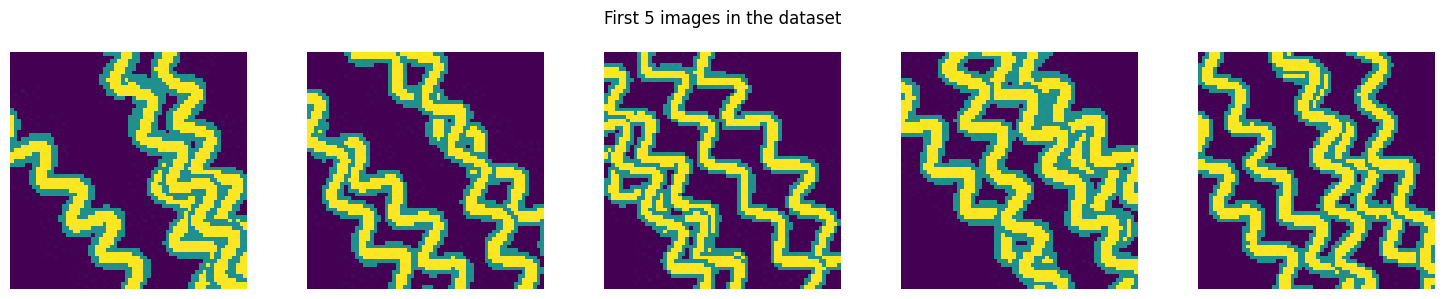

In [2]:
geomodels_dataset = [os.path.join(args.imgs_dir, img) for img in os.listdir(args.imgs_dir)][:4000]
N_data = len(geomodels_dataset)
to_tensor = T.Compose([T.ToTensor()])  # will give you floats in [0,1] and shape (C,H,W)

# load + convert each file
tensors = []
for fp in geomodels_dataset:
    img = Image.open(fp)   # or "RGB" if you have 3-channel images
    tensors.append(to_tensor(img))

# stack into one batch of shape (B,C,H,W)
dataset = torch.stack(tensors, dim=0)
print("Shape of the loaded dataset: ",list(dataset.shape))  # e.g. (4000,1,64,64)
indices = torch.randperm(len(dataset))[:5]
random_images = dataset[indices]

show_grid(random_images, n_cols=5, n_samples=5,title = "First 5 images in the dataset")

In [3]:
# define Guassian kernel
from scipy.stats import multivariate_normal
def norm_kernel(size = 9, sigma = 2):
    sig = sigma * np.eye(2)
    mean = np.zeros(2,)
    size_min = -(size - 1)/2
    size_max = (size - 1)/2
    x = np.linspace(size_min, size_max, size)
    y = np.linspace(size_min, size_max, size)
    xk, yk = np.meshgrid(x, y)
    kernel = np.zeros((size,size), dtype=np.float32)
    for i in range(size):
        for j in range(size):
            coord = np.squeeze([xk[i,j], yk[i,j]])
            kernel[i,j] = multivariate_normal.pdf(coord, mean=mean, cov=sig)
    kernel_sum = np.sum(kernel)
    kernel = kernel / kernel_sum
    return kernel

#### Probability maps

In [4]:
# Using Gaussian kernels with various size to smooth the indicator of channel complex to form the probability maps of channel complex with various blurriness. 

import scipy.signal as sig
prob_rlzs = np.zeros((dataset.shape), dtype=np.float32) # dimension = [35640, 8, 1, 64, 64]  
k =13
kernel = norm_kernel(size = k, sigma = k)  # size should be set to be odd
for num in range(dataset.shape[0]):
    cur_image = dataset[num,0].numpy()/255.0
    padvalue = np.mean(cur_image)
    prob_image = sig.convolve2d(cur_image, kernel, fillvalue = padvalue, mode='same') 
    prob_rlzs[num, 0] = prob_image 
prob_rlzs.shape

(4000, 1, 64, 64)

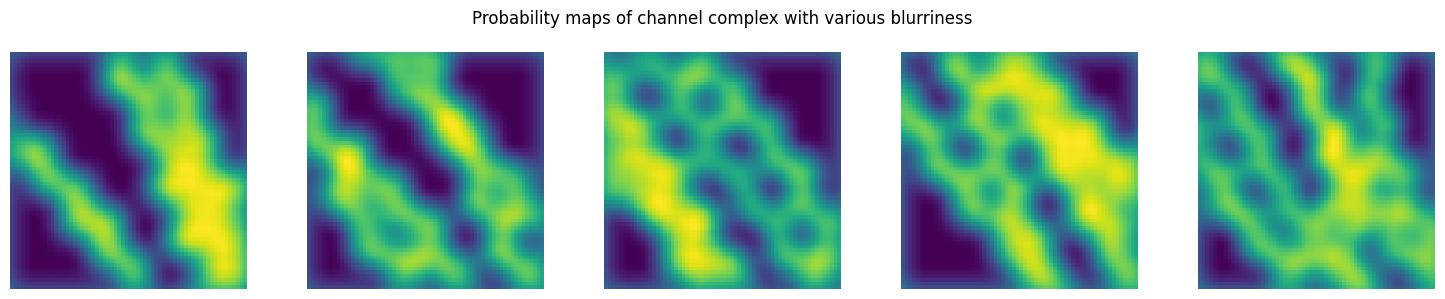

In [5]:
show_grid(prob_rlzs[indices],n_samples = 5, n_cols=5, title = "Probability maps of channel complex with various blurriness")

#### Well facies

Generated well facies shape: torch.Size([4000, 4, 64, 64])


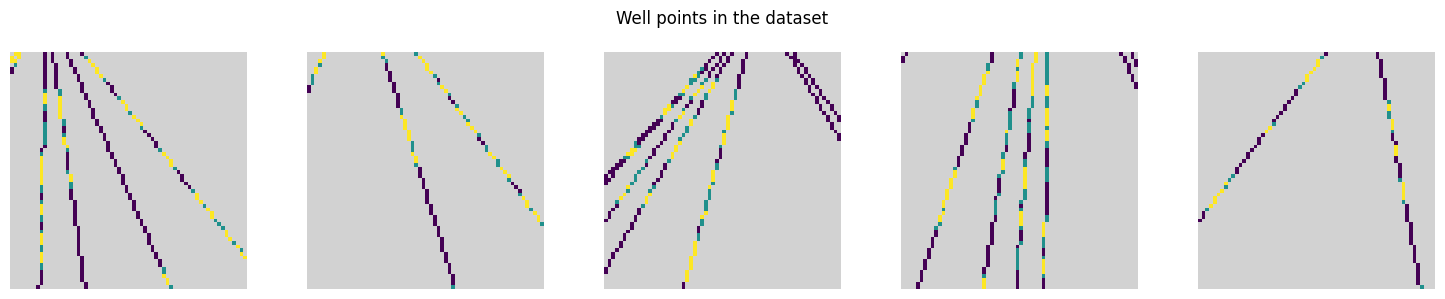

In [6]:
from matplotlib.colors import ListedColormap
well_facies = torch.from_numpy(x_to_well_facies(dataset, n_facies=3))  # (b c h w)
print(f"Generated well facies shape: {well_facies.shape}")
n_facies = 3
viridis = plt.get_cmap('viridis', 256)
colors = viridis(np.linspace(0, 1, n_facies))
# Add a contrasting color for the background
colors = np.vstack((colors[:, :3], [0.827, 0.827, 0.827]))  # Light grey
custom_cmap = ListedColormap(colors)
show_grid(torch.argmax(well_facies[-5:],1).unsqueeze(1), n_samples=5, n_cols=5, title="Well points in the dataset",cmap=custom_cmap, interpolation='nearest', vmin=0, vmax=n_facies)

### Sample to sample 

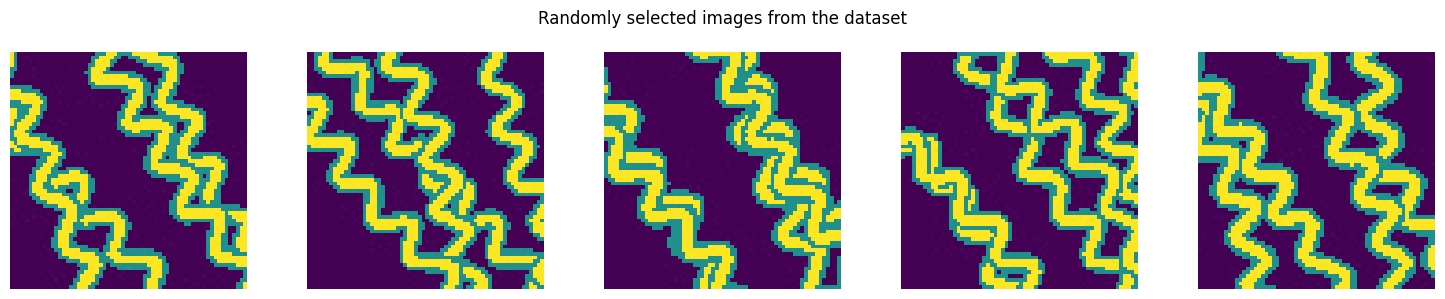

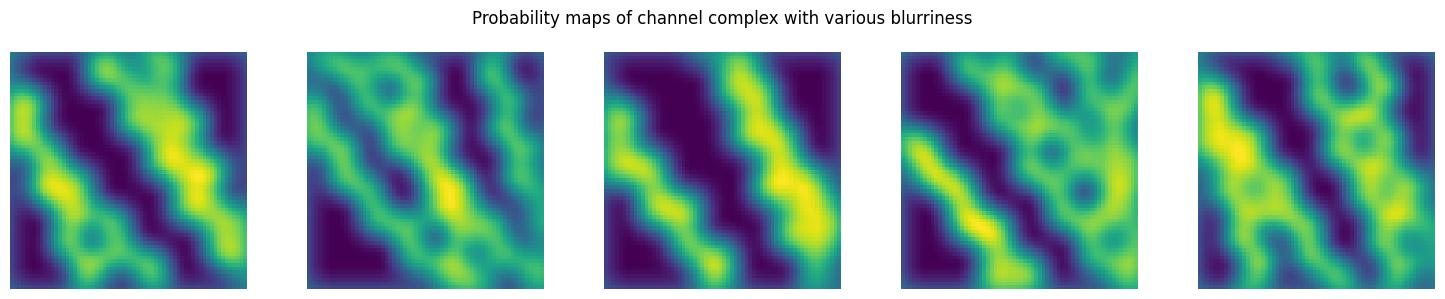

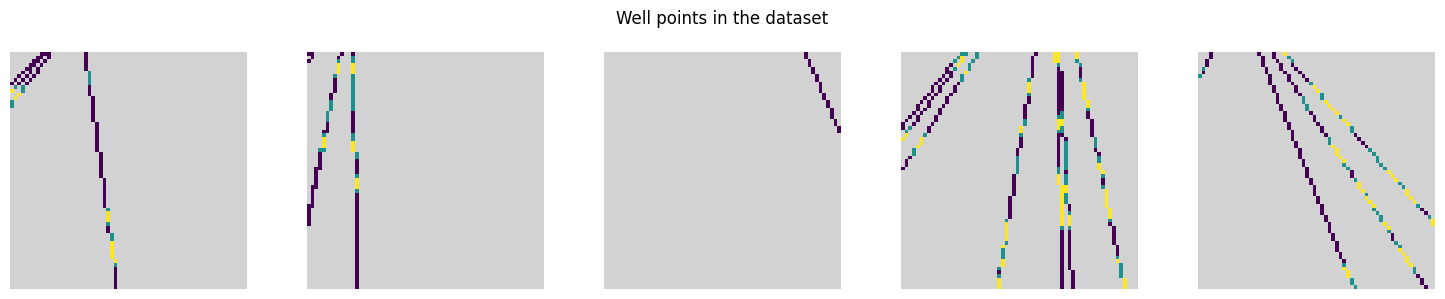

In [7]:
random_indicies = torch.randperm(len(dataset))[:5]
show_grid(dataset[random_indicies], n_samples=5, n_cols=5, title="Randomly selected images from the dataset")
show_grid(prob_rlzs[random_indicies], n_samples=5, n_cols=5, title="Probability maps of channel complex with various blurriness")
show_grid(torch.argmax(well_facies[random_indicies],1).unsqueeze(1), n_samples=5, n_cols=5, title="Well points in the dataset",cmap=custom_cmap, interpolation='nearest', vmin=0, vmax=n_facies)

In [8]:
prob_rlzs = torch.from_numpy(prob_rlzs)
torch.save(dataset, r"E:\code\monai\ldm_2d_geomodel\data\guido_dataset.pt")
torch.save(prob_rlzs, r"E:\code\monai\ldm_2d_geomodel\data\guido_prob_rlzs.pt")
torch.save(well_facies, r"E:\code\monai\ldm_2d_geomodel\data\guido_well_facies.pt")
print("Dataset, probability realizations, and well points saved successfully.")

Dataset, probability realizations, and well points saved successfully.
